# Output BAB 4.4.2 — Hasil Tuning Hyperparameter

Notebook ini khusus membuat artefak untuk subbab **4.4.2 Hasil Tuning Hyperparameter** sesuai `TODO_BAB_4_Lengkap.md` dan `TODO_BAB_4_Checklist_Output.md`. Output mencakup tabel grid search U-Net dan ProCANet, tabel gabungan dengan konfigurasi terbaik, heatmap, analisis efek learning rate/weight decay, narasi interpretasi, dan checklist cakupan TODO.


## 0. Setup

Konfigurasi path, folder output, plotting style, dan helper.


In [1]:
from __future__ import annotations

import json
import math
import re
from collections import Counter, defaultdict
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

try:
    import rasterio
except Exception as exc:
    rasterio = None
    RASTERIO_IMPORT_ERROR = f"{type(exc).__name__}: {exc}"
else:
    RASTERIO_IMPORT_ERROR = ""

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "font.size": 10,
})

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

DATASET = ROOT / "dataset"
RUNS = ROOT / "runs"
OUT = ROOT / "outputs" / "bab4"
TABLE_DIR = OUT / "tables"
FIG_DIR = OUT / "figures"
NARRATIVE_DIR = OUT / "narratives"
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
NARRATIVE_DIR.mkdir(parents=True, exist_ok=True)

REGIONS = [
    "Aceh_Besar", "Aceh_Tamiang", "Aceh_Timur", "Aceh_Utara", "Agam",
    "Banda_Aceh", "Bireuen", "Langsa", "Pasaman_Barat", "Pidie", "Pidie_Jaya",
]
TEST_REGION = "Aceh_Utara"
CHANNEL_NAMES = ["vv_norm", "vh_norm", "hue", "saturation", "value", "slope_norm", "hand_norm"]

print(f"ROOT: {ROOT}")
print(f"Tables: {TABLE_DIR}")
print(f"Figures: {FIG_DIR}")
print("rasterio:", "available" if rasterio else f"missing ({RASTERIO_IMPORT_ERROR})")


ROOT: /home/nozomi/Productive/skripsi
Tables: /home/nozomi/Productive/skripsi/outputs/bab4/tables
Figures: /home/nozomi/Productive/skripsi/outputs/bab4/figures
rasterio: available


In [2]:
def display_df(df: pd.DataFrame, max_rows: int = 20):
    if df.empty:
        display(df)
    else:
        display(df.head(max_rows))


def save_table(df: pd.DataFrame, name: str) -> Path:
    path = TABLE_DIR / name
    df.to_csv(path, index=False)
    print(f"saved table: {path.relative_to(ROOT)} ({len(df)} rows)")
    display_df(df)
    return path


def save_fig(fig, name: str) -> Path:
    path = FIG_DIR / name
    try:
        fig.tight_layout(rect=[0, 0, 1, 0.96])
    except Exception:
        fig.tight_layout()
    fig.savefig(path, bbox_inches="tight")
    print(f"saved figure: {path.relative_to(ROOT)}")
    plt.show()
    return path


def read_csv_or_status(path: Path, label: str) -> pd.DataFrame:
    if not path.exists():
        return pd.DataFrame([{"source": str(path.relative_to(ROOT)), "status": "missing", "note": label}])
    try:
        return pd.read_csv(path)
    except Exception as exc:
        return pd.DataFrame([{"source": str(path.relative_to(ROOT)), "status": "read_error", "note": f"{type(exc).__name__}: {exc}"}])


def safe_div(num: float, den: float) -> float:
    return float(num / den) if den else 0.0


def pct(num: float, den: float) -> float:
    return round(100.0 * safe_div(num, den), 4)


def finite_stats(arr: np.ndarray, sample_step: int = 1) -> dict:
    a = np.asarray(arr)
    if sample_step > 1 and a.ndim >= 2:
        a = a[..., ::sample_step, ::sample_step]
    a = a.astype("float64", copy=False)
    finite = np.isfinite(a)
    vals = a[finite]
    if vals.size == 0:
        return {"count": 0, "valid_pct": 0.0, "min": np.nan, "max": np.nan, "mean": np.nan, "std": np.nan, "p2": np.nan, "p98": np.nan}
    return {
        "count": int(vals.size),
        "valid_pct": round(100.0 * vals.size / a.size, 4),
        "min": float(np.min(vals)),
        "max": float(np.max(vals)),
        "mean": float(np.mean(vals)),
        "std": float(np.std(vals)),
        "p2": float(np.percentile(vals, 2)),
        "p98": float(np.percentile(vals, 98)),
    }


def normalize_image(arr: np.ndarray, p_low: float = 2, p_high: float = 98) -> np.ndarray:
    a = np.asarray(arr, dtype="float32")
    finite = np.isfinite(a)
    if not finite.any():
        return np.zeros_like(a, dtype="float32")
    lo, hi = np.percentile(a[finite], [p_low, p_high])
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        lo, hi = float(np.nanmin(a[finite])), float(np.nanmax(a[finite]))
    if hi <= lo:
        return np.zeros_like(a, dtype="float32")
    return np.clip((a - lo) / (hi - lo), 0, 1)


def raster_stats(path: Path, band: int = 1, sample_step: int = 10) -> dict:
    if rasterio is None:
        return {"status": "skipped", "note": f"rasterio unavailable: {RASTERIO_IMPORT_ERROR}"}
    if not path.exists():
        return {"status": "missing", "note": str(path.relative_to(ROOT))}
    try:
        with rasterio.open(path) as src:
            arr = src.read(band, masked=True)
            vals = arr.compressed() if np.ma.isMaskedArray(arr) else np.asarray(arr).ravel()
            if sample_step > 1:
                arr2 = np.asarray(arr.filled(np.nan) if np.ma.isMaskedArray(arr) else arr)
                vals = arr2[::sample_step, ::sample_step].ravel()
            stats = finite_stats(vals)
            stats.update({
                "status": "ok",
                "height": src.height,
                "width": src.width,
                "crs": str(src.crs),
                "transform": str(src.transform),
            })
            return stats
    except Exception as exc:
        return {"status": "read_error", "note": f"{type(exc).__name__}: {exc}"}


def load_npz(path: Path):
    return np.load(path, allow_pickle=False)


def first_npz(path: Path) -> Path | None:
    files = sorted(path.glob("*.npz"))
    return files[0] if files else None


def parse_tile_rc(path: Path) -> tuple[int | None, int | None]:
    m = re.search(r"_r(\d+)_c(\d+)", path.stem)
    if not m:
        return None, None
    return int(m.group(1)), int(m.group(2))


def choose_tile(region: str = TEST_REGION) -> Path | None:
    tile_dir = DATASET / "tiles" / "7ch" / "by_region" / region
    candidates = []
    for path in sorted(tile_dir.glob("*.npz")):
        try:
            z = load_npz(path)
            y = np.asarray(z["y"])[0]
            valid = np.asarray(z.get("valid_mask", np.ones_like(y)))[0]
            positives = int(((y > 0) & (valid > 0)).sum())
            valid_count = int((valid > 0).sum())
            candidates.append((positives, valid_count, path))
        except Exception:
            continue
    if not candidates:
        return None
    positives = [c for c in candidates if c[0] > 0]
    if positives:
        return sorted(positives, key=lambda x: x[0], reverse=True)[0][2]
    return sorted(candidates, key=lambda x: x[1], reverse=True)[0][2]


def find_matching_prediction(model: str, tile_path: Path) -> Path | None:
    pred_dir = RUNS / "final" / model / "eval_test" / "predictions" / TEST_REGION
    candidate = pred_dir / tile_path.name
    if candidate.exists():
        return candidate
    r, c = parse_tile_rc(tile_path)
    if r is None:
        return first_npz(pred_dir)
    matches = sorted(pred_dir.glob(f"*r{r:06d}_c{c:06d}.npz"))
    return matches[0] if matches else first_npz(pred_dir)


## 4.4.2 Load Run Tuning per Fold

Membaca seluruh `runs/<model>/fold_*/grid_lr_*_wd_*/metrics.csv` dan mengambil epoch terbaik berdasarkan validation IoU.


In [3]:
def parse_float(text: str) -> float:
    try:
        return float(text)
    except Exception:
        return np.nan


def pretty_model(model: str) -> str:
    return {"unet": "U-Net", "procanet": "ProCANet"}.get(str(model).lower(), str(model))


def load_tuning_runs() -> pd.DataFrame:
    rows = []
    for metrics_path in sorted(RUNS.glob("*/fold_*/grid_lr_*_wd_*/metrics.csv")):
        rel = metrics_path.relative_to(RUNS).parts
        model = rel[0]
        fold = rel[1]
        grid = rel[2]
        m = re.search(r"grid_lr_([^_]+)_wd_(.+)$", grid)
        learning_rate = m.group(1) if m else "unknown"
        weight_decay = m.group(2) if m else "unknown"
        try:
            df = pd.read_csv(metrics_path)
        except Exception as exc:
            rows.append({"model": pretty_model(model), "fold": fold, "grid": grid, "status": "read_error", "note": f"{type(exc).__name__}: {exc}"})
            continue
        if df.empty:
            rows.append({"model": pretty_model(model), "fold": fold, "grid": grid, "status": "empty"})
            continue
        best_col = "val_iou" if "val_iou" in df.columns else ("iou" if "iou" in df.columns else None)
        best_idx = df[best_col].idxmax() if best_col else df.index[-1]
        rec = df.loc[best_idx].to_dict()
        rows.append({
            "model": pretty_model(model),
            "fold": fold,
            "fold_index": int(str(fold).replace("fold_", "")) if str(fold).startswith("fold_") else np.nan,
            "variant": grid,
            "learning_rate": learning_rate,
            "learning_rate_value": parse_float(learning_rate),
            "weight_decay": weight_decay,
            "weight_decay_value": parse_float(weight_decay),
            "best_metric_column": best_col or "last_row",
            "best_epoch": int(rec.get("epoch", best_idx)),
            "best_val_iou": rec.get("val_iou", rec.get("iou", np.nan)),
            "best_val_dice": rec.get("val_dice", rec.get("dice", np.nan)),
            "best_val_loss": rec.get("val_loss", rec.get("loss", np.nan)),
            "final_lr": df["lr"].iloc[-1] if "lr" in df.columns else np.nan,
            "stopped_early": bool(df["stopped_early"].iloc[-1]) if "stopped_early" in df.columns else False,
            "metrics_path": str(metrics_path.relative_to(ROOT)),
            "status": "ok",
        })
    if not rows:
        return pd.DataFrame([{"status": "missing", "note": "No tuning metrics found under runs/*/fold_*/grid_lr_*_wd_*/metrics.csv"}])
    return pd.DataFrame(rows)

tuning_runs = load_tuning_runs()
save_table(tuning_runs, "4_4_2_hyperparameter_tuning_runs.csv")


saved table: outputs/bab4/tables/4_4_2_hyperparameter_tuning_runs.csv (60 rows)


,model,fold,fold_index,variant,learning_rate,learning_rate_value,weight_decay,weight_decay_value,best_metric_column,best_epoch,best_val_iou,best_val_dice,best_val_loss,final_lr,stopped_early,metrics_path,status
0,ProCANet,fold_0,0,grid_lr_1e-4_wd_1e-4,1e-4,0.00010,1e-4,0.00010,val_iou,18,0.819654,0.900890,0.655554,6.250000e-06,True,runs/procanet/fold_0/grid_lr_1e-4_wd_1e-4/metr...,ok
1,ProCANet,fold_0,0,grid_lr_1e-4_wd_1e-5,1e-4,0.00010,1e-5,0.00001,val_iou,22,0.818362,0.900109,0.637633,3.125000e-06,True,runs/procanet/fold_0/grid_lr_1e-4_wd_1e-5/metr...,ok
2,ProCANet,fold_0,0,grid_lr_1e-5_wd_1e-4,1e-5,0.00001,1e-4,0.00010,val_iou,16,0.742181,0.852013,0.940960,1.250000e-06,True,runs/procanet/fold_0/grid_lr_1e-5_wd_1e-4/metr...,ok
3,ProCANet,fold_0,0,grid_lr_1e-5_wd_1e-5,1e-5,0.00001,1e-5,0.00001,val_iou,12,0.752856,0.859005,0.884496,6.250000e-07,True,runs/procanet/fold_0/grid_lr_1e-5_wd_1e-5/metr...,ok
4,ProCANet,fold_0,0,grid_lr_5e-5_wd_1e-4,5e-5,0.00005,1e-4,0.00010,val_iou,25,0.811709,0.896070,0.681458,1.562500e-06,True,runs/procanet/fold_0/grid_lr_5e-5_wd_1e-4/metr...,ok
5,ProCANet,fold_0,0,grid_lr_5e-5_wd_1e-5,5e-5,0.00005,1e-5,0.00001,val_iou,31,0.811199,0.895759,0.711292,9.765625e-08,True,runs/procanet/fold_0/grid_lr_5e-5_wd_1e-5/metr...,ok
6,ProCANet,fold_1,1,grid_lr_1e-4_wd_1e-4,1e-4,0.00010,1e-4,0.00010,val_iou,17,0.753093,0.859159,0.442656,3.125000e-06,True,runs/procanet/fold_1/grid_lr_1e-4_wd_1e-4/metr...,ok
7,ProCANet,fold_1,1,grid_lr_1e-4_wd_1e-5,1e-4,0.00010,1e-5,0.00001,val_iou,12,0.754845,0.860298,0.480218,6.250000e-06,True,runs/procanet/fold_1/grid_lr_1e-4_wd_1e-5/metr...,ok
8,ProCANet,fold_1,1,grid_lr_1e-5_wd_1e-4,1e-5,0.00001,1e-4,0.00010,val_iou,36,0.728018,0.842604,0.800585,3.125000e-07,True,runs/procanet/fold_1/grid_lr_1e-5_wd_1e-4/metr...,ok
9,ProCANet,fold_1,1,grid_lr_1e-5_wd_1e-5,1e-5,0.00001,1e-5,0.00001,val_iou,29,0.727950,0.842559,0.665736,1.250000e-06,True,runs/procanet/fold_1/grid_lr_1e-5_wd_1e-5/metr...,ok


PosixPath('/home/nozomi/Productive/skripsi/outputs/bab4/tables/4_4_2_hyperparameter_tuning_runs.csv')

## 4.4.2 Ringkasan Grid Search

Mengagregasi hasil 5 fold per kombinasi learning rate dan weight decay, lalu menandai konfigurasi terbaik masing-masing model.


In [4]:
ok_runs = tuning_runs[tuning_runs.get("status", pd.Series(dtype=str)).eq("ok")].copy() if "status" in tuning_runs else pd.DataFrame()
if ok_runs.empty:
    tuning_summary = tuning_runs.copy()
else:
    group_cols = ["model", "variant", "learning_rate", "learning_rate_value", "weight_decay", "weight_decay_value"]
    tuning_summary = (
        ok_runs.groupby(group_cols, dropna=False)
        .agg(
            fold_count=("fold", "nunique"),
            mean_val_iou=("best_val_iou", "mean"),
            std_val_iou=("best_val_iou", "std"),
            mean_val_dice=("best_val_dice", "mean"),
            std_val_dice=("best_val_dice", "std"),
            mean_val_loss=("best_val_loss", "mean"),
            std_val_loss=("best_val_loss", "std"),
            mean_best_epoch=("best_epoch", "mean"),
            stopped_early_count=("stopped_early", "sum"),
        )
        .reset_index()
    )
    tuning_summary["std_val_iou"] = tuning_summary["std_val_iou"].fillna(0.0)
    tuning_summary["std_val_dice"] = tuning_summary["std_val_dice"].fillna(0.0)
    tuning_summary["std_val_loss"] = tuning_summary["std_val_loss"].fillna(0.0)
    tuning_summary["status"] = ""
    for model, g in tuning_summary.groupby("model"):
        best_idx = g["mean_val_iou"].idxmax()
        tuning_summary.loc[best_idx, "status"] = f"Terbaik {model}"
    tuning_summary = tuning_summary.sort_values(["model", "mean_val_iou"], ascending=[True, False])

save_table(tuning_summary, "4_4_2_hyperparameter_tuning_summary.csv")

for model in ["U-Net", "ProCANet"]:
    model_df = tuning_summary[tuning_summary.get("model", pd.Series(dtype=str)).eq(model)].copy()
    if not model_df.empty:
        safe = model.lower().replace("-", "").replace(" ", "_")
        save_table(model_df, f"4_4_2_grid_search_{safe}.csv")

best_configs = tuning_summary[tuning_summary.get("status", pd.Series(dtype=str)).astype(str).str.startswith("Terbaik")].copy()
save_table(best_configs, "4_4_2_best_hyperparameters_by_model.csv")


saved table: outputs/bab4/tables/4_4_2_hyperparameter_tuning_summary.csv (12 rows)


,model,variant,learning_rate,learning_rate_value,weight_decay,weight_decay_value,fold_count,mean_val_iou,std_val_iou,mean_val_dice,std_val_dice,mean_val_loss,std_val_loss,mean_best_epoch,stopped_early_count,status
0,ProCANet,grid_lr_1e-4_wd_1e-4,1e-4,0.00010,1e-4,0.00010,5,0.653125,0.172251,0.778533,0.140022,0.707865,0.216545,18.4,5,Terbaik ProCANet
1,ProCANet,grid_lr_1e-4_wd_1e-5,1e-4,0.00010,1e-5,0.00001,5,0.649184,0.177177,0.774832,0.145274,0.671351,0.141368,14.6,5,
5,ProCANet,grid_lr_5e-5_wd_1e-5,5e-5,0.00005,1e-5,0.00001,5,0.648864,0.156262,0.777613,0.124733,0.749445,0.157696,19.2,5,
4,ProCANet,grid_lr_5e-5_wd_1e-4,5e-5,0.00005,1e-4,0.00010,5,0.640883,0.176156,0.768751,0.144753,0.731853,0.177386,23.0,5,
2,ProCANet,grid_lr_1e-5_wd_1e-4,1e-5,0.00001,1e-4,0.00010,5,0.619554,0.144583,0.756513,0.120367,0.956861,0.126875,17.0,5,
3,ProCANet,grid_lr_1e-5_wd_1e-5,1e-5,0.00001,1e-5,0.00001,5,0.618258,0.145909,0.755423,0.120613,0.888990,0.159672,20.8,5,
10,U-Net,grid_lr_5e-5_wd_1e-4,5e-5,0.00005,1e-4,0.00010,5,0.642336,0.167470,0.771095,0.136785,0.770414,0.169830,21.2,5,Terbaik U-Net
7,U-Net,grid_lr_1e-4_wd_1e-5,1e-4,0.00010,1e-5,0.00001,5,0.638076,0.163852,0.768464,0.132797,0.720479,0.118998,20.4,5,
11,U-Net,grid_lr_5e-5_wd_1e-5,5e-5,0.00005,1e-5,0.00001,5,0.637268,0.170264,0.766844,0.139946,0.785387,0.148085,16.0,5,
6,U-Net,grid_lr_1e-4_wd_1e-4,1e-4,0.00010,1e-4,0.00010,5,0.630595,0.183078,0.759639,0.154303,0.706666,0.113836,21.4,5,


saved table: outputs/bab4/tables/4_4_2_grid_search_unet.csv (6 rows)


,model,variant,learning_rate,learning_rate_value,weight_decay,weight_decay_value,fold_count,mean_val_iou,std_val_iou,mean_val_dice,std_val_dice,mean_val_loss,std_val_loss,mean_best_epoch,stopped_early_count,status
10,U-Net,grid_lr_5e-5_wd_1e-4,5e-5,0.00005,1e-4,0.00010,5,0.642336,0.167470,0.771095,0.136785,0.770414,0.169830,21.2,5,Terbaik U-Net
7,U-Net,grid_lr_1e-4_wd_1e-5,1e-4,0.00010,1e-5,0.00001,5,0.638076,0.163852,0.768464,0.132797,0.720479,0.118998,20.4,5,
11,U-Net,grid_lr_5e-5_wd_1e-5,5e-5,0.00005,1e-5,0.00001,5,0.637268,0.170264,0.766844,0.139946,0.785387,0.148085,16.0,5,
6,U-Net,grid_lr_1e-4_wd_1e-4,1e-4,0.00010,1e-4,0.00010,5,0.630595,0.183078,0.759639,0.154303,0.706666,0.113836,21.4,5,
8,U-Net,grid_lr_1e-5_wd_1e-4,1e-5,0.00001,1e-4,0.00010,5,0.608386,0.153888,0.746509,0.131061,0.926067,0.075498,23.4,5,
9,U-Net,grid_lr_1e-5_wd_1e-5,1e-5,0.00001,1e-5,0.00001,5,0.552798,0.284198,0.665823,0.316295,0.989187,0.207843,16.8,4,


saved table: outputs/bab4/tables/4_4_2_grid_search_procanet.csv (6 rows)


,model,variant,learning_rate,learning_rate_value,weight_decay,weight_decay_value,fold_count,mean_val_iou,std_val_iou,mean_val_dice,std_val_dice,mean_val_loss,std_val_loss,mean_best_epoch,stopped_early_count,status
0,ProCANet,grid_lr_1e-4_wd_1e-4,1e-4,0.00010,1e-4,0.00010,5,0.653125,0.172251,0.778533,0.140022,0.707865,0.216545,18.4,5,Terbaik ProCANet
1,ProCANet,grid_lr_1e-4_wd_1e-5,1e-4,0.00010,1e-5,0.00001,5,0.649184,0.177177,0.774832,0.145274,0.671351,0.141368,14.6,5,
5,ProCANet,grid_lr_5e-5_wd_1e-5,5e-5,0.00005,1e-5,0.00001,5,0.648864,0.156262,0.777613,0.124733,0.749445,0.157696,19.2,5,
4,ProCANet,grid_lr_5e-5_wd_1e-4,5e-5,0.00005,1e-4,0.00010,5,0.640883,0.176156,0.768751,0.144753,0.731853,0.177386,23.0,5,
2,ProCANet,grid_lr_1e-5_wd_1e-4,1e-5,0.00001,1e-4,0.00010,5,0.619554,0.144583,0.756513,0.120367,0.956861,0.126875,17.0,5,
3,ProCANet,grid_lr_1e-5_wd_1e-5,1e-5,0.00001,1e-5,0.00001,5,0.618258,0.145909,0.755423,0.120613,0.888990,0.159672,20.8,5,


saved table: outputs/bab4/tables/4_4_2_best_hyperparameters_by_model.csv (2 rows)


,model,variant,learning_rate,learning_rate_value,weight_decay,weight_decay_value,fold_count,mean_val_iou,std_val_iou,mean_val_dice,std_val_dice,mean_val_loss,std_val_loss,mean_best_epoch,stopped_early_count,status
0,ProCANet,grid_lr_1e-4_wd_1e-4,1e-4,0.00010,1e-4,0.0001,5,0.653125,0.172251,0.778533,0.140022,0.707865,0.216545,18.4,5,Terbaik ProCANet
10,U-Net,grid_lr_5e-5_wd_1e-4,5e-5,0.00005,1e-4,0.0001,5,0.642336,0.167470,0.771095,0.136785,0.770414,0.169830,21.2,5,Terbaik U-Net


PosixPath('/home/nozomi/Productive/skripsi/outputs/bab4/tables/4_4_2_best_hyperparameters_by_model.csv')

## 4.4.2 Heatmap dan Grafik Perbandingan

Membuat heatmap mean validation IoU untuk U-Net dan ProCANet serta grafik perbandingan kombinasi hyperparameter.


saved figure: outputs/bab4/figures/4_4_2_hyperparameter_heatmap_procanet.png


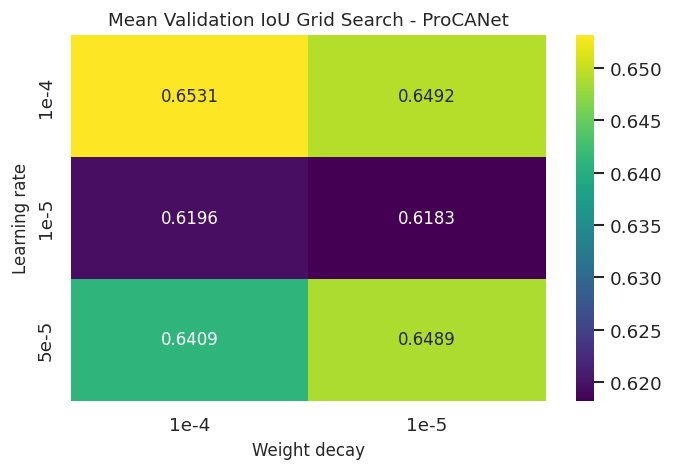

saved figure: outputs/bab4/figures/4_4_2_hyperparameter_heatmap_unet.png


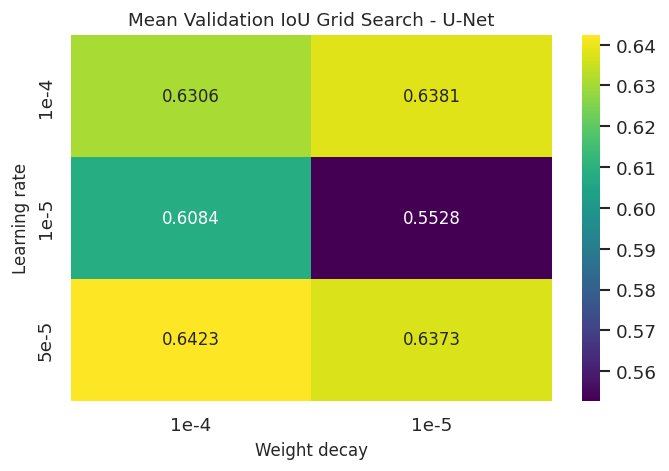

saved figure: outputs/bab4/figures/4_4_2_hyperparameter_mean_iou_comparison.png


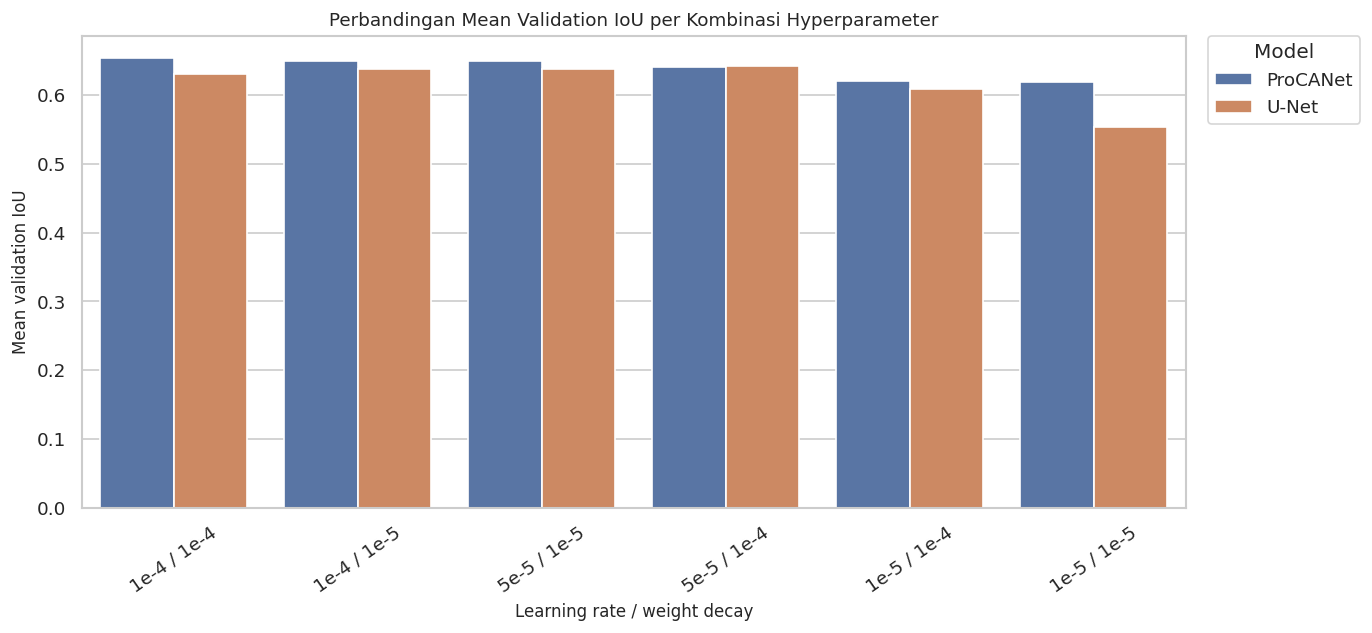

In [5]:
if not ok_runs.empty:
    for model, g in tuning_summary.groupby("model"):
        pivot = g.pivot_table(index="learning_rate", columns="weight_decay", values="mean_val_iou", aggfunc="max")
        fig, ax = plt.subplots(figsize=(5.8, 4.2))
        sns.heatmap(pivot, annot=True, fmt=".4f", cmap="viridis", ax=ax)
        ax.set_title(f"Mean Validation IoU Grid Search - {model}")
        ax.set_xlabel("Weight decay")
        ax.set_ylabel("Learning rate")
        safe = model.lower().replace("-", "").replace(" ", "_")
        save_fig(fig, f"4_4_2_hyperparameter_heatmap_{safe}.png")

    # Combined comparison table-like bar chart for mean IoU.
    plot_df = tuning_summary.copy()
    plot_df["label"] = plot_df["learning_rate"] + " / " + plot_df["weight_decay"]
    fig, ax = plt.subplots(figsize=(11.5, 5.6))
    sns.barplot(data=plot_df, x="label", y="mean_val_iou", hue="model", ax=ax)
    ax.set_title("Perbandingan Mean Validation IoU per Kombinasi Hyperparameter")
    ax.set_xlabel("Learning rate / weight decay")
    ax.set_ylabel("Mean validation IoU")
    ax.tick_params(axis="x", rotation=35)
    ax.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
    fig.tight_layout(rect=[0, 0, 0.84, 1])
    save_fig(fig, "4_4_2_hyperparameter_mean_iou_comparison.png")


## 4.4.2 Efek Learning Rate dan Weight Decay

Meringkas pengaruh marginal learning rate dan weight decay terhadap rata-rata validation IoU/Dice/Loss.


In [6]:
effect_rows = []
if not ok_runs.empty:
    for model, g in ok_runs.groupby("model"):
        for lr, lr_group in g.groupby("learning_rate"):
            effect_rows.append({
                "model": model,
                "factor": "learning_rate",
                "level": lr,
                "run_count": len(lr_group),
                "mean_best_val_iou": lr_group["best_val_iou"].mean(),
                "mean_best_val_dice": lr_group["best_val_dice"].mean(),
                "mean_best_val_loss": lr_group["best_val_loss"].mean(),
            })
        for wd, wd_group in g.groupby("weight_decay"):
            effect_rows.append({
                "model": model,
                "factor": "weight_decay",
                "level": wd,
                "run_count": len(wd_group),
                "mean_best_val_iou": wd_group["best_val_iou"].mean(),
                "mean_best_val_dice": wd_group["best_val_dice"].mean(),
                "mean_best_val_loss": wd_group["best_val_loss"].mean(),
            })
hyperparameter_effects = pd.DataFrame(effect_rows)
save_table(hyperparameter_effects, "4_4_2_hyperparameter_factor_effects.csv")


saved table: outputs/bab4/tables/4_4_2_hyperparameter_factor_effects.csv (10 rows)


,model,factor,level,run_count,mean_best_val_iou,mean_best_val_dice,mean_best_val_loss
0,ProCANet,learning_rate,1e-4,10,0.651155,0.776682,0.689608
1,ProCANet,learning_rate,1e-5,10,0.618906,0.755968,0.922925
2,ProCANet,learning_rate,5e-5,10,0.644874,0.773182,0.740649
3,ProCANet,weight_decay,1e-4,15,0.637854,0.767932,0.798859
4,ProCANet,weight_decay,1e-5,15,0.638769,0.769289,0.769929
5,U-Net,learning_rate,1e-4,10,0.634336,0.764052,0.713572
6,U-Net,learning_rate,1e-5,10,0.580592,0.706166,0.957627
7,U-Net,learning_rate,5e-5,10,0.639802,0.768969,0.777901
8,U-Net,weight_decay,1e-4,15,0.627106,0.759081,0.801049
9,U-Net,weight_decay,1e-5,15,0.609381,0.733710,0.831684


PosixPath('/home/nozomi/Productive/skripsi/outputs/bab4/tables/4_4_2_hyperparameter_factor_effects.csv')

## 4.4.2 Narasi Interpretasi

Menyimpan paragraf siap pakai tentang konfigurasi terbaik, efek learning rate, efek weight decay, dan keterbatasan ruang grid search.


In [7]:
def best_text(model: str) -> str:
    if "best_configs" not in globals() or best_configs.empty:
        return f"{model}: tidak tersedia"
    row = best_configs[best_configs["model"].eq(model)]
    if row.empty:
        return f"{model}: tidak tersedia"
    r = row.iloc[0]
    return f"{model}: {r['variant']} (lr={r['learning_rate']}, weight decay={r['weight_decay']}, mean Val IoU={r['mean_val_iou']:.4f}, mean Dice={r['mean_val_dice']:.4f})"

def factor_sentence(model: str, factor: str) -> str:
    if "hyperparameter_effects" not in globals() or hyperparameter_effects.empty:
        return "data efek faktor tidak tersedia"
    df = hyperparameter_effects[(hyperparameter_effects["model"].eq(model)) & (hyperparameter_effects["factor"].eq(factor))]
    if df.empty:
        return "data efek faktor tidak tersedia"
    best = df.sort_values("mean_best_val_iou", ascending=False).iloc[0]
    worst = df.sort_values("mean_best_val_iou", ascending=True).iloc[0]
    return f"level terbaik {best['level']} (mean IoU {best['mean_best_val_iou']:.4f}) dan terendah {worst['level']} (mean IoU {worst['mean_best_val_iou']:.4f})"

combo_count = int(tuning_summary.groupby(["learning_rate", "weight_decay"]).ngroups) if "tuning_summary" in globals() and not tuning_summary.empty else 0
run_count = int(len(ok_runs)) if "ok_runs" in globals() else 0
fold_count = int(ok_runs["fold"].nunique()) if "ok_runs" in globals() and not ok_runs.empty else 0

interpretation_text = f"""# Interpretasi Tuning Hyperparameter 4.4.2

Grid search dilakukan pada {combo_count} kombinasi learning rate dan weight decay untuk masing-masing model, dievaluasi pada {fold_count} fold spatial cross-validation sehingga total run yang terbaca adalah {run_count}. Konfigurasi terbaik dipilih berdasarkan rata-rata validation IoU antar-fold, bukan berdasarkan satu fold tunggal.

Konfigurasi terbaik yang diperoleh adalah {best_text('U-Net')} dan {best_text('ProCANet')}. Pemilihan berdasarkan mean validation IoU membuat konfigurasi lebih stabil terhadap variasi wilayah validasi dibanding memilih checkpoint dari satu wilayah saja.

Pengaruh learning rate terlihat dari perbedaan rata-rata IoU antar level. Pada U-Net, {factor_sentence('U-Net', 'learning_rate')}. Pada ProCANet, {factor_sentence('ProCANet', 'learning_rate')}. Learning rate yang terlalu kecil cenderung membuat pembelajaran lebih lambat, sedangkan learning rate yang lebih besar perlu dibaca bersama stabilitas validation IoU pada tiap fold.

Weight decay berperan sebagai regularisasi parameter. Pada U-Net, {factor_sentence('U-Net', 'weight_decay')}. Pada ProCANet, {factor_sentence('ProCANet', 'weight_decay')}. Jika weight decay yang lebih tinggi memberi IoU lebih baik, hal tersebut mengindikasikan regularisasi membantu menekan overfitting; sebaliknya, jika nilainya menurun, regularisasi dapat terlalu membatasi kemampuan model belajar.

Keterbatasan tuning ini adalah ruang pencarian masih sempit, yaitu hanya {combo_count} kombinasi learning rate dan weight decay. Eksperimen belum mengeksplorasi batch size, base channel, loss weight, augmentasi, scheduler alternatif, atau threshold inferensi. Karena itu, hasil tuning cukup untuk memilih konfigurasi eksperimen utama, tetapi belum dapat dianggap sebagai optimasi hyperparameter yang menyeluruh.
"""
path = NARRATIVE_DIR / "4_4_2_hyperparameter_tuning_interpretation.md"
path.write_text(interpretation_text, encoding="utf-8")
print(f"saved narrative: {path.relative_to(ROOT)}")
print(interpretation_text)
path


saved narrative: outputs/bab4/narratives/4_4_2_hyperparameter_tuning_interpretation.md
# Interpretasi Tuning Hyperparameter 4.4.2

Grid search dilakukan pada 6 kombinasi learning rate dan weight decay untuk masing-masing model, dievaluasi pada 5 fold spatial cross-validation sehingga total run yang terbaca adalah 60. Konfigurasi terbaik dipilih berdasarkan rata-rata validation IoU antar-fold, bukan berdasarkan satu fold tunggal.

Konfigurasi terbaik yang diperoleh adalah U-Net: grid_lr_5e-5_wd_1e-4 (lr=5e-5, weight decay=1e-4, mean Val IoU=0.6423, mean Dice=0.7711) dan ProCANet: grid_lr_1e-4_wd_1e-4 (lr=1e-4, weight decay=1e-4, mean Val IoU=0.6531, mean Dice=0.7785). Pemilihan berdasarkan mean validation IoU membuat konfigurasi lebih stabil terhadap variasi wilayah validasi dibanding memilih checkpoint dari satu wilayah saja.

Pengaruh learning rate terlihat dari perbedaan rata-rata IoU antar level. Pada U-Net, level terbaik 5e-5 (mean IoU 0.6398) dan terendah 1e-5 (mean IoU 0.5806). P

PosixPath('/home/nozomi/Productive/skripsi/outputs/bab4/narratives/4_4_2_hyperparameter_tuning_interpretation.md')

## Checklist 4.4.2

Memverifikasi artefak 4.4.2 yang diminta TODO.


In [8]:
expected = [
    ("wajib", "Tabel grid search gabungan U-Net dan ProCANet", TABLE_DIR / "4_4_2_hyperparameter_tuning_summary.csv"),
    ("wajib", "Tabel grid search U-Net", TABLE_DIR / "4_4_2_grid_search_unet.csv"),
    ("wajib", "Tabel grid search ProCANet", TABLE_DIR / "4_4_2_grid_search_procanet.csv"),
    ("wajib", "Tabel konfigurasi terbaik per model", TABLE_DIR / "4_4_2_best_hyperparameters_by_model.csv"),
    ("disarankan", "Heatmap grid search U-Net", FIG_DIR / "4_4_2_hyperparameter_heatmap_unet.png"),
    ("disarankan", "Heatmap grid search ProCANet", FIG_DIR / "4_4_2_hyperparameter_heatmap_procanet.png"),
    ("disarankan", "Grafik perbandingan mean IoU", FIG_DIR / "4_4_2_hyperparameter_mean_iou_comparison.png"),
    ("disarankan", "Tabel efek learning rate dan weight decay", TABLE_DIR / "4_4_2_hyperparameter_factor_effects.csv"),
    ("narasi_wajib", "Interpretasi learning rate, weight decay, dan keterbatasan grid search", NARRATIVE_DIR / "4_4_2_hyperparameter_tuning_interpretation.md"),
    ("lampiran", "Tabel run per fold", TABLE_DIR / "4_4_2_hyperparameter_tuning_runs.csv"),
]
checklist_4_4_2 = pd.DataFrame([
    {"priority": p, "todo_item": item, "artifact": str(path.relative_to(ROOT)), "exists": path.exists(), "size_bytes": path.stat().st_size if path.exists() else 0}
    for p, item, path in expected
])
save_table(checklist_4_4_2, "4_4_2_todo_coverage_checklist.csv")
missing = checklist_4_4_2[~checklist_4_4_2["exists"]]
if missing.empty:
    print("All 4.4.2 TODO artifacts created.")
else:
    print("Missing 4.4.2 artifacts:")
    display(missing)


saved table: outputs/bab4/tables/4_4_2_todo_coverage_checklist.csv (10 rows)


,priority,todo_item,artifact,exists,size_bytes
0,wajib,Tabel grid search gabungan U-Net dan ProCANet,outputs/bab4/tables/4_4_2_hyperparameter_tunin...,True,2364
1,wajib,Tabel grid search U-Net,outputs/bab4/tables/4_4_2_grid_search_unet.csv,True,1278
2,wajib,Tabel grid search ProCANet,outputs/bab4/tables/4_4_2_grid_search_procanet...,True,1299
3,wajib,Tabel konfigurasi terbaik per model,outputs/bab4/tables/4_4_2_best_hyperparameters...,True,596
4,disarankan,Heatmap grid search U-Net,outputs/bab4/figures/4_4_2_hyperparameter_heat...,True,98219
5,disarankan,Heatmap grid search ProCANet,outputs/bab4/figures/4_4_2_hyperparameter_heat...,True,100501
6,disarankan,Grafik perbandingan mean IoU,outputs/bab4/figures/4_4_2_hyperparameter_mean...,True,120608
7,disarankan,Tabel efek learning rate dan weight decay,outputs/bab4/tables/4_4_2_hyperparameter_facto...,True,942
8,narasi_wajib,"Interpretasi learning rate, weight decay, dan ...",outputs/bab4/narratives/4_4_2_hyperparameter_t...,True,2043
9,lampiran,Tabel run per fold,outputs/bab4/tables/4_4_2_hyperparameter_tunin...,True,12076


All 4.4.2 TODO artifacts created.
